##  Image Processing in HSV Color Space (OpenCV)

#### 📌 Overview

In this section, we explore the **HSV color space (Hue, Saturation, Value)** and how it can be used for image manipulation.

HSV is often more intuitive than RGB because it separates:
- **Hue (H):** color type  
- **Saturation (S):** color intensity  
- **Value (V):** brightness  

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Load image in BGR format (OpenCV default)
img_bgr = cv2.imread("bird.jpg")

# Convert to RGB (for correct visualization in Matplotlib)
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

# Convert to HSV color space
img_hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)

#### 📌 Compare Color Spaces


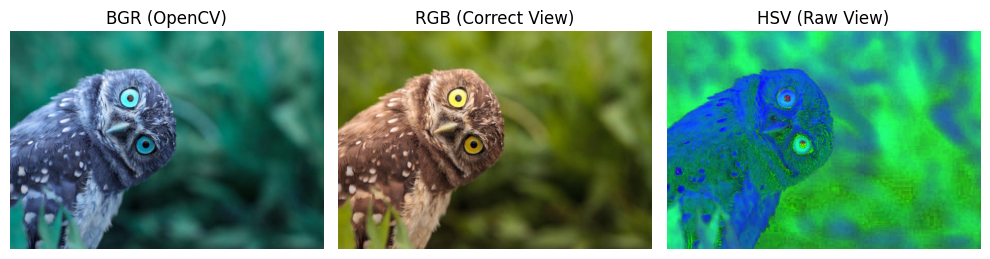

In [3]:
plt.figure(figsize=(10, 5))

plt.subplot(1, 3, 1)
plt.imshow(img_bgr)
plt.title("BGR (OpenCV)")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(img_rgb)
plt.title("RGB (Correct View)")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(img_hsv)
plt.title("HSV (Raw View)")
plt.axis("off")

plt.tight_layout()
plt.show()


📌 Note:
- HSV image is not visually meaningful when displayed directly with `imshow`.

#### 📌 Step 4: Modify Brightness (V Channel)

We increase brightness by adding a constant value to the **V channel**.

In [8]:
#  Split HSV Channels

h, s, v = cv2.split(img_hsv)

print("H shape:", h.shape)
print("S shape:", s.shape)
print("V shape:", v.shape)


# Increase brightness
v_new = cv2.add(v, 20)

# Merge channels back
img_hsv_new = cv2.merge([h, s, v_new])

# Convert back to RGB for visualization
img_rgb_new = cv2.cvtColor(img_hsv_new, cv2.COLOR_HSV2RGB)

H shape: (425, 612)
S shape: (425, 612)
V shape: (425, 612)


#### 📌 Compare Original vs Modified Image


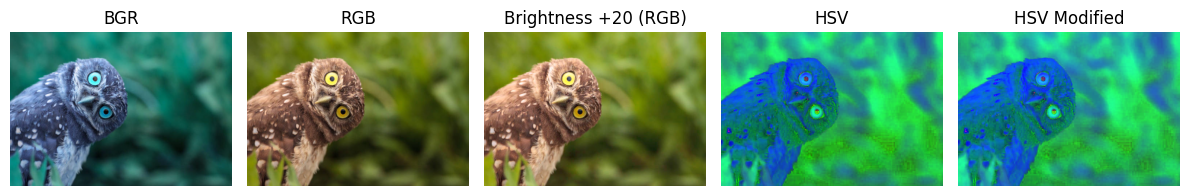

In [9]:
plt.figure(figsize=(12, 6))

plt.subplot(1, 5, 1)
plt.imshow(img_bgr)
plt.title("BGR")
plt.axis("off")

plt.subplot(1, 5, 2)
plt.imshow(img_rgb)
plt.title("RGB")
plt.axis("off")

plt.subplot(1, 5, 3)
plt.imshow(img_rgb_new)
plt.title("Brightness +20 (RGB)")
plt.axis("off")

plt.subplot(1, 5, 4)
plt.imshow(img_hsv)
plt.title("HSV")
plt.axis("off")

plt.subplot(1, 5, 5)
plt.imshow(img_hsv_new)
plt.title("HSV Modified")
plt.axis("off")

plt.tight_layout()
plt.show()

####  Working with Saturation


To remove color information (convert image toward grayscale-like appearance), we set saturation to zero:


In [11]:
def show_hsv_image(img_hsv):
    img_rgb = cv2.cvtColor(img_hsv, cv2.COLOR_HSV2RGB)
    print("Image shape:", img_rgb.shape)
    plt.imshow(img_rgb)
    plt.axis("off")
    plt.show()

Image shape: (425, 612, 3)


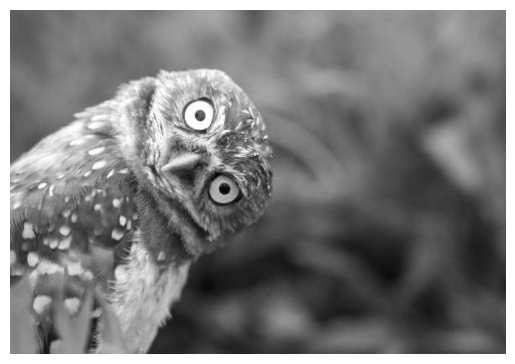

In [12]:
# Remove saturation (make image grayscale-like)
img_hsv[:, :, 1] = 0
show_hsv_image(img_hsv)


## Contrast Analysis Using HSV


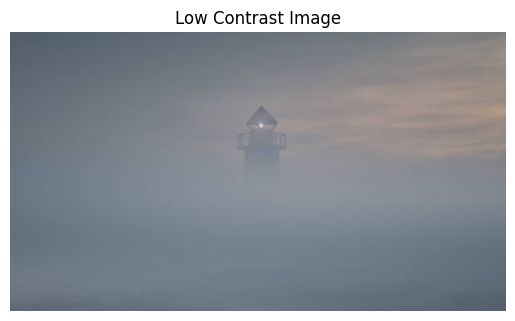

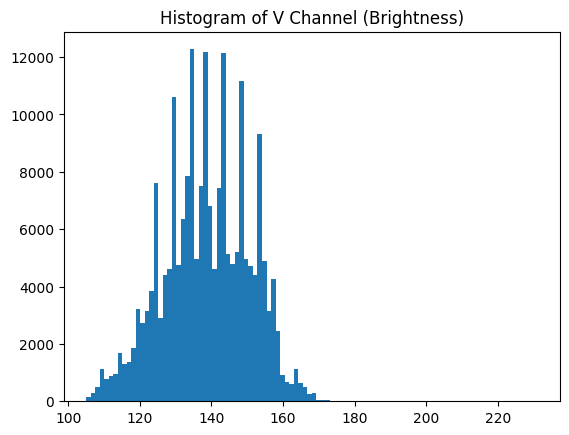

In [13]:
# Load low contrast image
img_bgr = cv2.imread("lowcontrast2.jpg")
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
img_hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)

plt.imshow(img_rgb)
plt.title("Low Contrast Image")
plt.axis("off")
plt.show()

# Extract V channel
h, s, v = cv2.split(img_hsv)

# Plot intensity distribution
plt.hist(v.flatten(), bins=100)
plt.title("Histogram of V Channel (Brightness)")
plt.show()

## 🚀 Summary

- HSV separates color and brightness into independent channels.
- The **V channel controls brightness**, making it ideal for enhancement.
- Modifying HSV is more stable than RGB for image editing.
- Histogram of **V channel** shows brightness distribution clearly.